In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


In [3]:
df = pd.read_csv('example_data_1_PHYS_433_533.csv')
print(df)

      f_res  max_power_dBm
0      3000          -54.0
1      3002          -54.1
2      3004          -54.0
3      3006          -53.9
4      3008          -53.8
...     ...            ...
996    4992          -63.8
997    4994          -63.3
998    4996          -63.3
999    4998          -63.8
1000   5000          -64.2

[1001 rows x 2 columns]


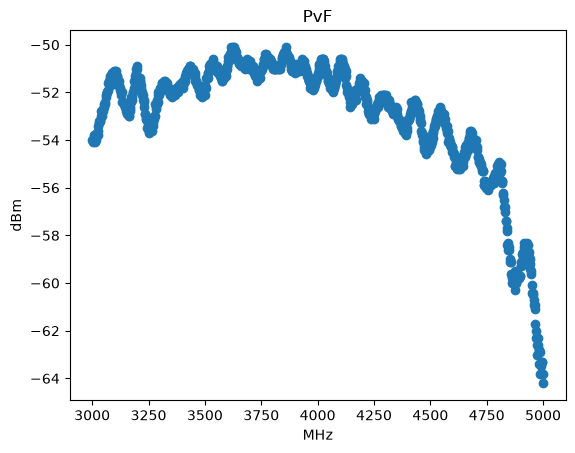

In [6]:
frequency = df['f_res']
power_dBm = df['max_power_dBm']
plt.title("PvF")
plt.xlabel("MHz")
plt.ylabel("dBm")
plt.scatter(frequency,power_dBm)
plt.show()

In [7]:
power_mW=10**(np.array(power_dBm)/10)
print(power_mW[:5])

[3.98107171e-06 3.89045145e-06 3.98107171e-06 4.07380278e-06
 4.16869383e-06]


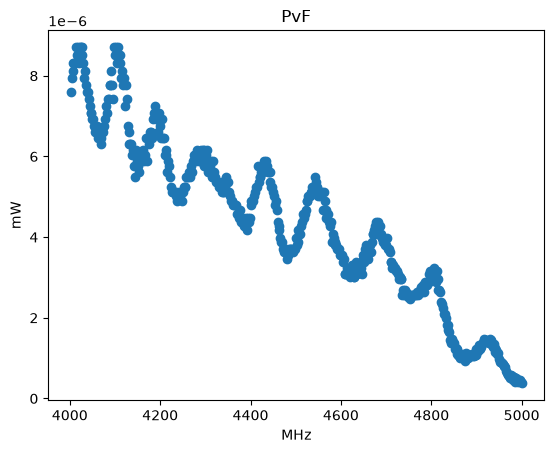

In [10]:
mask = frequency >4000
freq_trimmed=frequency[mask]
pow_trimmed=power_mW[mask]
plt.title("PvF")
plt.xlabel("MHz")
plt.ylabel("mW")
plt.scatter(freq_trimmed,pow_trimmed)
plt.show()

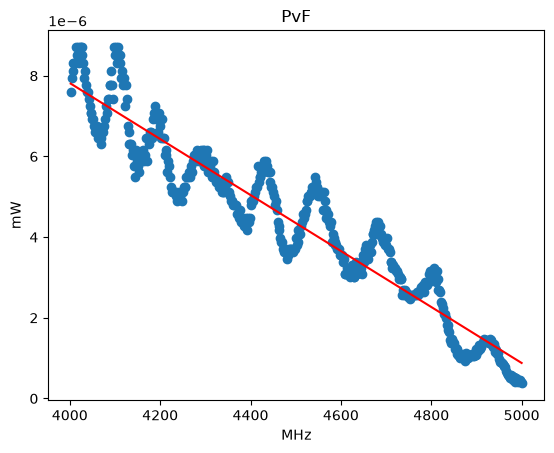

In [21]:
def linear_fit(x,m,b):
    return m*x+b
popt,pcov = curve_fit(linear_fit,freq_trimmed,pow_trimmed,p0=(-1,40e-6))
perr=np.sqrt(np.diag(pcov))
plt.title("PvF")
plt.xlabel("MHz")
plt.ylabel("mW")
plt.scatter(freq_trimmed,pow_trimmed)
plt.plot(freq_trimmed, linear_fit(freq_trimmed,popt[0],popt[1]),color='red')
plt.show()